In [1]:
%matplotlib inline
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynapple as nap
from IPython.display import display

from spatial_manifolds.detect_grids import compute_vr_tcs, get_kmeans_spatial_labels
from spatial_manifolds.toroidal import spectral_analysis

In [2]:
SOURCE_PATH   = '/Users/harryclark/Downloads/COHORT12/'
CELLS_CSV     = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv'
CATALOGUE_DIR = Path('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/catalogue')
CATALOGUE_DIR.mkdir(exist_ok=True)

bs  = 2      # cm per spatial bin
tl  = 200    # VR track length (cm)
TARGET_FREQS = np.arange(1, 6) * bs / tl

CONDITIONS = ['cued_anchored', 'cued_unanchored', 'uncued_anchored', 'uncued_unanchored']
CON_LABELS = ['Beaconed\nAnchored', 'Beaconed\nUnanchored',
              'Unbeaconed\nAnchored', 'Unbeaconed\nUnanchored']

# Anchored family = warm, unanchored family = cool — consistent across trial types
#   [0] cued_anchored     red     [1] cued_unanchored     blue
#   [2] uncued_anchored   orange  [3] uncued_unanchored   grey
CON_COLORS = ['#c04744', '#3171ae', '#e8963e', '#aaaaaa']

REGIONS         = ['ENT', 'VIS', 'PAR', 'PRE', 'SUB']
GC_TYPES        = ('GC', 'cmGC', 'ncmGC')
MEDLAT_BOUNDARY = 3400   # µm in coord_SCs_x

In [3]:
def _prep(df):
    df['mouse']      = df['mouse'].astype(int)
    df['day']        = df['day'].astype(int)
    df['cluster_id'] = df['cluster_id'].astype(int)
    return df

df_all = _prep(pd.read_csv(CELLS_CSV))
all_sessions = sorted(set(map(tuple, df_all[['mouse', 'day']].values.tolist())))
print(f'Sessions: {len(all_sessions)}  Total cells: {len(df_all)}')

Sessions: 79  Total cells: 11115


In [4]:
def compute_anchoring_labels(cid, tcs):
    tc = tcs.get(cid)
    if tc is None or len(tc) == 0:
        return None
    try:
        _DUMMY = cid + 100000
        results     = spectral_analysis({cid: tc, _DUMMY: tc}, tl, bs)
        fvalid      = results[5]
        freq_idx    = [int(np.argmin(np.abs(fvalid - f))) for f in TARGET_FREQS]
        lbl_per_win = np.isin(np.argmax(results[3][0], axis=0), freq_idx).astype(int)
        labels = get_kmeans_spatial_labels(tc, lbl_per_win, bs=bs, tl=tl).astype(float)
        edge = int(1600 / (2 * (tl / bs)))
        labels[:edge]  = np.nan
        labels[-edge:] = np.nan
        return labels
    except Exception:
        return None

In [5]:
def _simplify_region(reg):
    for prefix in ('ENT', 'VIS', 'PAR', 'PRE', 'SUB'):
        if reg.upper().startswith(prefix):
            return prefix
    return reg[:3] if len(reg) >= 3 else reg

_locs = pd.read_csv(f'{SOURCE_PATH}/all_cluster_brain_locations_chris.csv')
_locs['coord_SCs_x'] = _locs['coord_SCs_x'] * -1

def _medlat(mouse, day, cluster_id):
    row = _locs[
        (_locs['mouse'] == mouse) &
        (_locs['day'] == day) &
        (_locs['cluster_id'] == cluster_id)
    ]
    if row.empty:
        return np.nan
    return 'medial' if row['coord_SCs_x'].values[0] < MEDLAT_BOUNDARY else 'lateral'

def _make_boxplot(ax, sub, rng, title):
    data = [sub[c].dropna().values for c in CONDITIONS]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='k', lw=1.5),
                    whiskerprops=dict(lw=0.8, color='#555'),
                    capprops=dict(lw=0.8, color='#555'),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markeredgewidth=0))
    for patch, color in zip(bp['boxes'], CON_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
    for xi, (d, color) in enumerate(zip(data, CON_COLORS), start=1):
        jitter = rng.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(xi + jitter, d, color=color, s=7, alpha=0.45, zorder=3, edgecolors='none')
    ax.set_xticks(range(1, len(CONDITIONS) + 1))
    ax.set_xticklabels(CON_LABELS, fontsize=7)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_ylim(0, 100)

In [6]:
condition_rows = []

for mouse, day in all_sessions:
    try:
        tcs, _, _, _, beh, _ = compute_vr_tcs(mouse, day, source_path=SOURCE_PATH)
    except Exception as e:
        print(f'M{mouse}D{day}: load error {e}'); continue
    try:
        trial_types   = np.array(beh['trials']['type'])
        trial_perfs   = np.array(beh['trials'].performance)
        beaconed_mask = trial_types == 'b'
        unbeac_mask   = trial_types == 'nb'
    except Exception as e:
        print(f'M{mouse}D{day}: trial col error {e}'); continue

    _sess = df_all[(df_all['mouse'] == mouse) & (df_all['day'] == day)]
    for _, row in _sess.iterrows():
        lab = compute_anchoring_labels(int(row['cluster_id']), tcs)
        if lab is None:
            continue
        region = _simplify_region(str(row.get('brain_region', 'unknown')))
        n_t    = len(lab)
        tp     = trial_perfs[:n_t]
        anch   = lab.astype(bool)

        def _pct_hits(type_mask, anch_mask):
            mask  = type_mask[:n_t] & anch_mask
            total = mask.sum()
            return 100 * np.sum(tp[mask] == 'hit') / total if total > 0 else np.nan

        condition_rows.append({
            'mouse':             mouse,
            'day':               day,
            'cluster_id':        int(row['cluster_id']),
            'region':            region,
            'cell_type':         str(row.get('cell_type', '')),
            'cued_anchored':     _pct_hits(beaconed_mask,  anch),
            'cued_unanchored':   _pct_hits(beaconed_mask, ~anch),
            'uncued_anchored':   _pct_hits(unbeac_mask,    anch),
            'uncued_unanchored': _pct_hits(unbeac_mask,   ~anch),
        })

df_cond = pd.DataFrame(condition_rows)
print(f'{len(df_cond)} cells, {df_cond.groupby(["mouse","day"]).ngroups} sessions (all sessions)')
print(df_cond.groupby('region')[CONDITIONS].mean().round(1))

11088 cells, 79 sessions (all sessions)
        cued_anchored  cued_unanchored  uncued_anchored  uncued_unanchored
region                                                                    
APr              93.0             86.0             66.3               55.3
ENT              77.2             78.4             50.7               50.3
HPF              79.8             83.6             52.4               49.7
PAR              86.0             89.6             62.0               64.4
POS              91.0             96.0             66.8               69.4
PRE              76.9             84.8             54.8               60.3
RSP              68.2             74.1             19.4               21.5
SUB              90.6             85.1             59.3               64.8
VIS              83.6             83.0             58.8               58.9
dhc              84.2             85.7             63.9               63.3
ec               90.2             91.1             56.2     

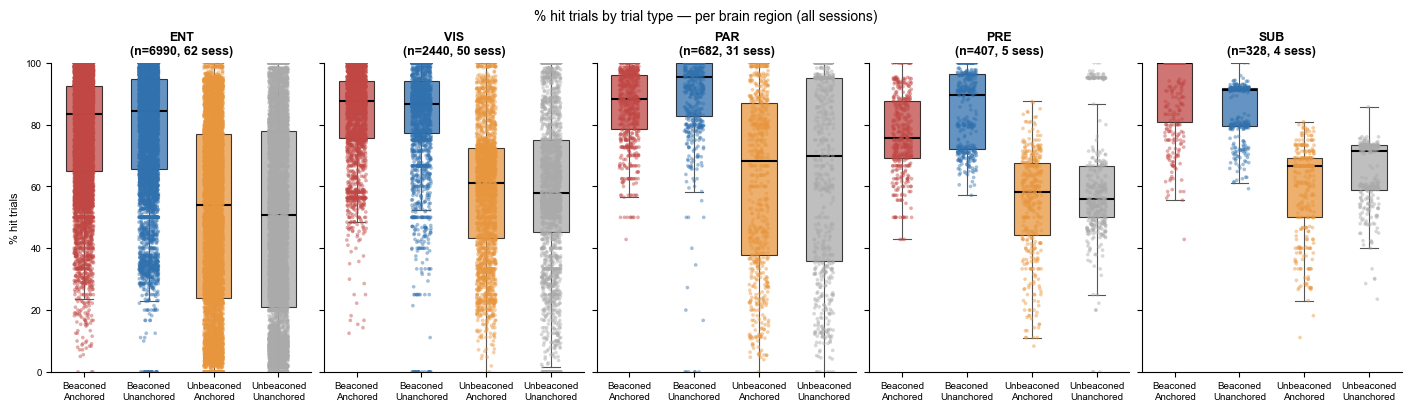

In [7]:
regions_present = [r for r in REGIONS if r in df_cond['region'].values]
n_reg = len(regions_present)
fig, axes = plt.subplots(1, n_reg, figsize=(2.8 * n_reg, 4),
                         sharey=True, constrained_layout=True)
if n_reg == 1:
    axes = [axes]
rng = np.random.default_rng(0)

for ax, reg in zip(axes, regions_present):
    sub = df_cond[df_cond['region'] == reg]
    n_sess_reg = sub.groupby(['mouse', 'day']).ngroups
    _make_boxplot(ax, sub, rng, f'{reg}\n(n={len(sub)}, {n_sess_reg} sess)')

axes[0].set_ylabel('% hit trials', fontsize=8)
fig.suptitle('% hit trials by trial type — per brain region (all sessions)', fontsize=10)
fig.savefig(CATALOGUE_DIR / 'all_sessions_anchoring_by_region.pdf', bbox_inches='tight', dpi=200)
display(fig); plt.close()

ENT GC: 616 cells, 58 sessions


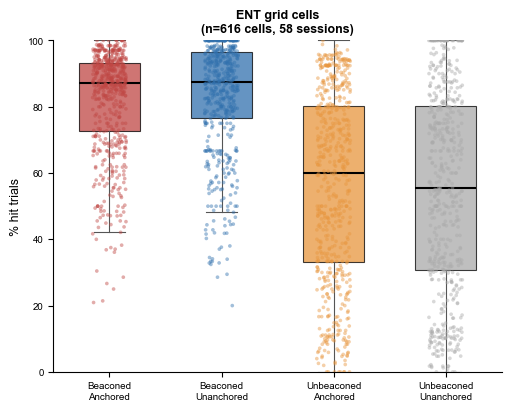

In [8]:
df_ent_gc = df_cond[
    (df_cond['region'] == 'ENT') &
    (df_cond['cell_type'].isin(GC_TYPES))
].copy()

n_sess_gc = df_ent_gc.groupby(['mouse', 'day']).ngroups
print(f'ENT GC: {len(df_ent_gc)} cells, {n_sess_gc} sessions')

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
rng = np.random.default_rng(0)
_make_boxplot(ax, df_ent_gc, rng,
              f'ENT grid cells\n(n={len(df_ent_gc)} cells, {n_sess_gc} sessions)')
ax.set_ylabel('% hit trials', fontsize=9)
fig.savefig(CATALOGUE_DIR / 'all_sessions_anchoring_ENT_GC.pdf', bbox_inches='tight', dpi=200)
display(fig); plt.close()

ent_location
medial     388
lateral    228
Name: count, dtype: int64


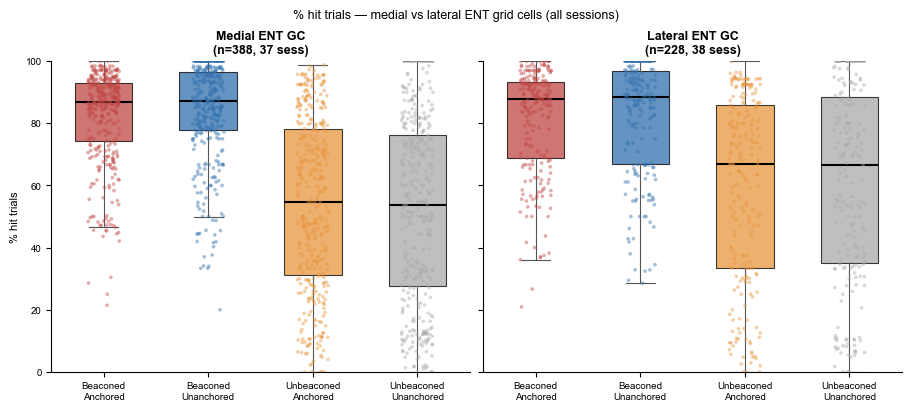

In [9]:
df_ent_gc['ent_location'] = df_ent_gc.apply(
    lambda r: _medlat(r['mouse'], r['day'], r['cluster_id']), axis=1
)
print(df_ent_gc['ent_location'].value_counts())

locations_present = [l for l in ('medial', 'lateral')
                     if l in df_ent_gc['ent_location'].values]
fig, axes = plt.subplots(1, len(locations_present),
                         figsize=(4.5 * len(locations_present), 4),
                         sharey=True, constrained_layout=True)
if len(locations_present) == 1:
    axes = [axes]
rng = np.random.default_rng(0)

for ax, loc in zip(axes, locations_present):
    sub = df_ent_gc[df_ent_gc['ent_location'] == loc]
    n_sess_loc = sub.groupby(['mouse', 'day']).ngroups
    _make_boxplot(ax, sub, rng,
                  f'{loc.capitalize()} ENT GC\n(n={len(sub)}, {n_sess_loc} sess)')

axes[0].set_ylabel('% hit trials', fontsize=8)
fig.suptitle('% hit trials — medial vs lateral ENT grid cells (all sessions)', fontsize=9)
fig.savefig(CATALOGUE_DIR / 'all_sessions_anchoring_ENT_GC_medlat.pdf',
            bbox_inches='tight', dpi=200)
display(fig); plt.close()

ent_location
lateral    4720
medial     2270
Name: count, dtype: int64
ent_location  cell_type
lateral       GC            228
              NG           3686
              Other         806
medial        GC            388
              NG           1575
              Other         307
dtype: int64


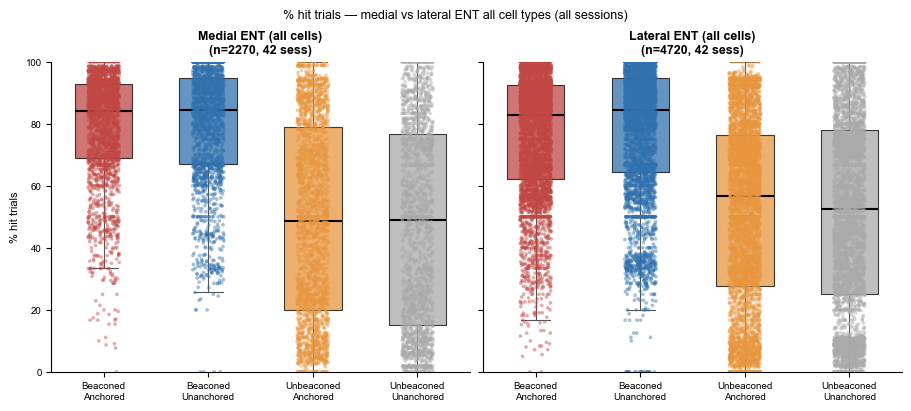

In [10]:
df_ent_all = df_cond[df_cond['region'] == 'ENT'].copy()
df_ent_all['ent_location'] = df_ent_all.apply(
    lambda r: _medlat(r['mouse'], r['day'], r['cluster_id']), axis=1
)
print(df_ent_all['ent_location'].value_counts())
print(df_ent_all.groupby(['ent_location', 'cell_type']).size())

locations_present = [l for l in ('medial', 'lateral')
                     if l in df_ent_all['ent_location'].values]
fig, axes = plt.subplots(1, len(locations_present),
                         figsize=(4.5 * len(locations_present), 4),
                         sharey=True, constrained_layout=True)
if len(locations_present) == 1:
    axes = [axes]
rng = np.random.default_rng(0)

for ax, loc in zip(axes, locations_present):
    sub = df_ent_all[df_ent_all['ent_location'] == loc]
    n_sess_loc = sub.groupby(['mouse', 'day']).ngroups
    _make_boxplot(ax, sub, rng,
                  f'{loc.capitalize()} ENT (all cells)\n(n={len(sub)}, {n_sess_loc} sess)')

axes[0].set_ylabel('% hit trials', fontsize=8)
fig.suptitle('% hit trials — medial vs lateral ENT all cell types (all sessions)', fontsize=9)
fig.savefig(CATALOGUE_DIR / 'all_sessions_anchoring_ENT_all_medlat.pdf',
            bbox_inches='tight', dpi=200)
display(fig); plt.close()

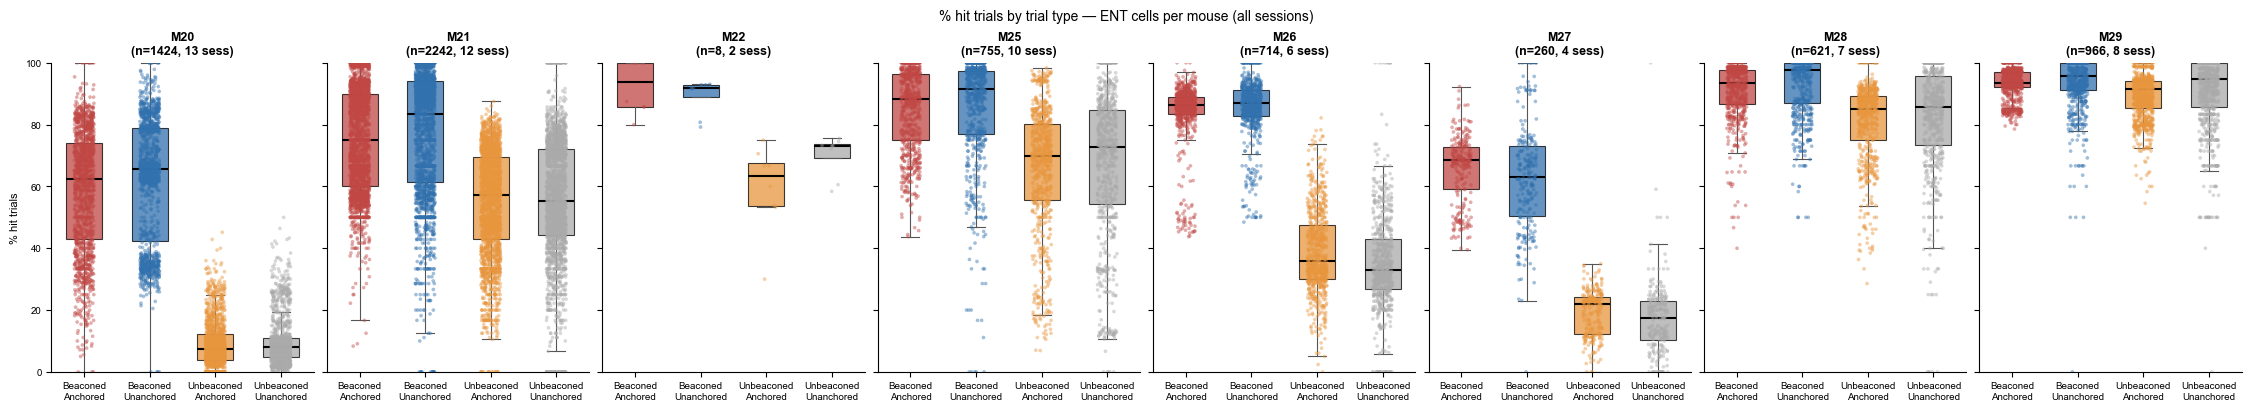

In [11]:
df_ent = df_cond[df_cond['region'] == 'ENT'].copy()

mice = sorted(df_ent['mouse'].unique())
n_mice = len(mice)

fig, axes = plt.subplots(1, n_mice, figsize=(2.8 * n_mice, 4),
                         sharey=True, constrained_layout=True)
if n_mice == 1:
    axes = [axes]

rng = np.random.default_rng(0)

for ax, mouse in zip(axes, mice):
    sub = df_ent[df_ent['mouse'] == mouse]
    n_sess_m = sub.groupby('day').ngroups
    _make_boxplot(ax, sub, rng,
                  f'M{mouse}\n(n={len(sub)}, {n_sess_m} sess)')

axes[0].set_ylabel('% hit trials', fontsize=8)
fig.suptitle('% hit trials by trial type — ENT cells per mouse (all sessions)', fontsize=10)
fig.savefig(CATALOGUE_DIR / 'all_sessions_anchoring_ENT_per_mouse.pdf',
            bbox_inches='tight', dpi=200)
display(fig); plt.close()
